In [1]:
!pip install "numpy<2" roboticstoolbox-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.2 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 54.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 60.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.7/114.7 MB 7.9 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 124.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193

In [1]:
import roboticstoolbox as rtb
import numpy as np
from spatialmath import SE3

# --- 1. SYSTEM VARIABLES AND CONSTANTS ---
H1 = 0.4   
L0 = 1.1   
L1 = 0.3   
L2 = 0.1   
H4 = 0.1   
L3 = 0.1   
L4 = 0.5   

# --- 2. DEFINE LINKS (Matches Table 1 in PDF) ---
links = [
    # Joint 1: Revolute (Theta1)
    # alpha=0, a=0, d=H1+L0, theta=q1
    rtb.RevoluteMDH(alpha=0, a=0, d=(H1 + L0), offset=0, qlim=[0, 2*np.pi]),

    # Joint 2: Prismatic (d2)
    # alpha=90, a=0, d=d2+L1, theta=0
    rtb.PrismaticMDH(alpha=np.pi/2, a=0, theta=0, offset=L1, qlim=[0.3, 1.5]),

    # Joint 3: Prismatic (d3)
    # alpha=90, a=0, d=d3+(L2+H4+L3), theta=90 (CORRECTED based on Table 1)
    rtb.PrismaticMDH(alpha=np.pi/2, a=0, theta=np.pi/2, offset=(L2 + H4 + L3), qlim=[0.1, 0.15]),

    # Joint 4: Revolute (Theta4)
    # alpha=0, a=0, d=0, theta=q4
    rtb.RevoluteMDH(alpha=0, a=0, d=0, offset=0, qlim=[0, 2*np.pi])
]

# Create Robot
robot = rtb.DHRobot(links, name='4DOF_Bot')

# --- 3. DEFINE TOOL (Link 4->5) ---
# Translation of L4 along x
robot.tool = SE3.Tx(L4)

print("--- ROBOT DEFINITION ---")
print(robot)

# --- 4. CALCULATE MATRICES ---
# Test Config: q = [30 deg, 0.5, 0.12, 45 deg]
q_test = np.array([np.deg2rad(30), 0.5, 0.12, np.deg2rad(45)])

print(f"\n--- CALCULATED MATRICES for q = {np.round(q_test, 3)} ---")

# Matrix Calculation Loop
T_accumulated = SE3()

for i, link in enumerate(robot.links):
    matrix_Ai = link.A(q_test[i])
    print(f"\n[Matrix A{i+1}] (Link {i}->{i+1}):")
    # We round to 3 decimals for easy reading
    print(np.round(matrix_Ai.A, 3))
    T_accumulated = T_accumulated * matrix_Ai

# --- 5. VERIFICATION OF FINAL POSE ---
print("\n[Total T] (Base -> Tool Flange):")
print(np.round(T_accumulated.A, 3))

print("\n[Final End-Effector Pose] (Base -> Tip):")
final_pose = robot.fkine(q_test)
print(np.round(final_pose.A, 3))

# --- 6. AUTOMATIC CHECKER (Equation 7) ---
# Pz = (H1 + L0) - (d3 + L2 + H4 + L3)
Pz_toolbox = final_pose.A[2, 3]
# Using q_test[2] which is d3 (0.12)
Pz_manual = (H1 + L0) - (q_test[2] + L2 + H4 + L3)

print("\n--- CRITICAL CHECK ---")
print(f"Manual Pz Calculation: {Pz_manual:.3f}")
print(f"Toolbox Pz Output:     {Pz_toolbox:.3f}")

if abs(Pz_toolbox - Pz_manual) < 0.001:
    print(">>> VERIFICATION SUCCESSFUL: The toolbox matches your Equation 7.")
else:
    print(">>> VERIFICATION FAILED: Check offsets again.")

--- ROBOT DEFINITION ---
DHRobot: 4DOF_Bot, 4 joints (RPPR), dynamics, modified DH parameters
┌──────┬───────┬───────┬───────────────────────────┬──────┬────────┐
│ aⱼ₋₁ │ ⍺ⱼ₋₁  │  θⱼ   │            dⱼ             │  q⁻  │   q⁺   │
├──────┼───────┼───────┼───────────────────────────┼──────┼────────┤
│    0 │  0.0° │    q1 │                       1.5 │ 0.0° │ 360.0° │
│    0 │ 90.0° │  0.0° │                  q2 + 0.3 │  0.3 │    1.5 │
│    0 │ 90.0° │ 90.0° │  q3 + 0.30000000000000004 │  0.1 │   0.15 │
│    0 │  0.0° │    q4 │                         0 │ 0.0° │ 360.0° │
└──────┴───────┴───────┴───────────────────────────┴──────┴────────┘

┌──────┬─────────────────────────────────────┐
│ tool │ t = 0.5, 0, 0; rpy/xyz = 0°, 0°, 0° │
└──────┴─────────────────────────────────────┘


--- CALCULATED MATRICES for q = [0.524 0.5   0.12  0.785] ---

[Matrix A1] (Link 0->1):
[[ 0.866 -0.5    0.     0.   ]
 [ 0.5    0.866 -0.    -0.   ]
 [ 0.     0.     1.     1.5  ]
 [ 0.     0.     0.     1.   

Plotting Volume: R=[0.10, 2.30], Z=[1.05, 1.10]


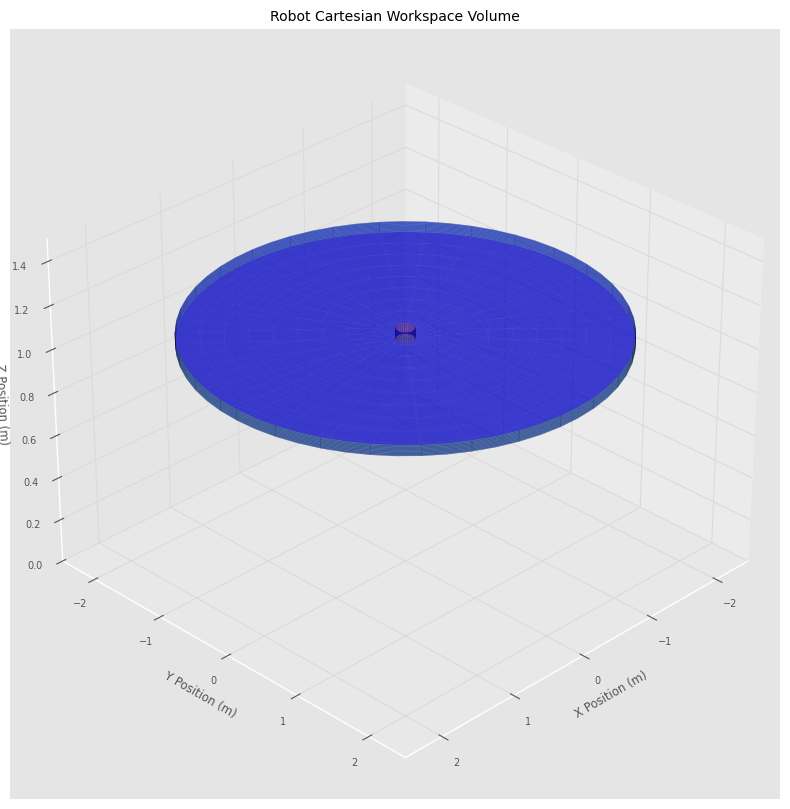

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# --- 1. SYSTEM PARAMETERS ---
H1, L0 = 0.4, 1.1
L1 = 0.3
L2 = 0.1
H4, L3 = 0.1, 0.1
L4 = 0.5

d2_min, d2_max = 0.3, 1.5
d3_min, d3_max = 0.1, 0.15

# --- 2. CALCULATE BOUNDARIES ---
# Z limits (d3 extends downwards, so min d3 = max Z)
Z_max = (H1 + L0) - (d3_min + L2 + H4 + L3)
Z_min = (H1 + L0) - (d3_max + L2 + H4 + L3)

# Radius limits
# Max reach is fully extended arm + tool
R_max = (d2_max + L1) + L4
# Min reach is retracted arm - tool length (folding back)
R_min = abs((d2_min + L1) - L4)

print(f"Plotting Volume: R=[{R_min:.2f}, {R_max:.2f}], Z=[{Z_min:.2f}, {Z_max:.2f}]")

# --- 3. PLOT SETUP ---
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# --- 4. GENERATE MESH DATA ---
# Angular resolution (0 to 360)
theta = np.linspace(0, 2*np.pi, 60)
# Height resolution (Bottom to Top)
z = np.linspace(Z_min, Z_max, 10)
theta_grid, z_grid = np.meshgrid(theta, z)

# A. Outer Cylinder (Max Reach)
x_outer = R_max * np.cos(theta_grid)
y_outer = R_max * np.sin(theta_grid)
ax.plot_surface(x_outer, y_outer, z_grid, color='cyan', alpha=0.3, edgecolor='black', linewidth=0.2)

# B. Inner Cylinder (Min Reach)
x_inner = R_min * np.cos(theta_grid)
y_inner = R_min * np.sin(theta_grid)
ax.plot_surface(x_inner, y_inner, z_grid, color='red', alpha=0.3, edgecolor='black', linewidth=0.2)

# C. Caps (Top and Bottom Rings)
r = np.linspace(R_min, R_max, 10)
r_grid, theta_grid = np.meshgrid(r, theta)
x_cap = r_grid * np.cos(theta_grid)
y_cap = r_grid * np.sin(theta_grid)

# Top Cap
z_top = np.full_like(x_cap, Z_max)
ax.plot_surface(x_cap, y_cap, z_top, color='blue', alpha=0.5)

# Bottom Cap
z_bot = np.full_like(x_cap, Z_min)
ax.plot_surface(x_cap, y_cap, z_bot, color='blue', alpha=0.5)

# --- 5. IMPORTANT VIEWING SETTINGS ---
ax.set_xlabel('X Position (m)')
ax.set_ylabel('Y Position (m)')
ax.set_zlabel('Z Position (m)')
ax.set_title('Robot Cartesian Workspace Volume')

# FORCE THE Z-LIMITS so the plot doesn't look empty
ax.set_zlim(1.0, 1.5) 
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)

# Set the viewing angle (Elevation, Azimuth)
ax.view_init(elev=30, azim=45)

plt.show()

In [ ]:
import numpy as np

# --- 1. SYSTEM PARAMETERS ---
H1, L0 = 0.4, 1.1
L1 = 0.3
L2 = 0.1
H4, L3 = 0.1, 0.1
L4 = 0.5

# --- 2. DEFINE ANALYTICAL FK (Eq 7) ---
def forward_kinematics_analytical(q):
    t1, d2, d3, t4 = q
    # Based on PDF Eq 7:
    # x = L4*sin(t1-t4) + (d2+L1)*sin(t1)
    # y = -L4*cos(t1-t4) - (d2+L1)*cos(t1)
    # z = (H1+L0) - (d3+L2+H4+L3)
    # phi = t1 - t4
    
    phi = t1 - t4
    px = L4 * np.sin(phi) + (d2 + L1) * np.sin(t1)
    py = -L4 * np.cos(phi) - (d2 + L1) * np.cos(t1)
    pz = (H1 + L0) - (d3 + L2 + H4 + L3)
    
    return np.array([px, py, pz, phi])

# --- 3. DEFINE ANALYTICAL JACOBIAN (Eq 10) ---
def jacobian_analytical(q):
    t1, d2, d3, t4 = q
    s1, c1 = np.sin(t1), np.cos(t1)
    s14, c14 = np.sin(t1 - t4), np.cos(t1 - t4)
    
    # Rows: [Vx, Vy, Vz, Wz] (Simplified 4x4 for verification)
    J = np.zeros((4, 4))
    
    # Row 1: Vx (matches Eq 10 in PDF)
    # dx/dt1 = L4*cos(t1-t4) + (d2+L1)*cos(t1)
    J[0, 0] = L4 * c14 + (d2 + L1) * c1
    # dx/dd2 = sin(t1)
    J[0, 1] = s1
    # dx/dt4 = -L4*cos(t1-t4)
    J[0, 3] = -L4 * c14
    
    # Row 2: Vy
    # dy/dt1 = L4*sin(t1-t4) + (d2+L1)*sin(t1)
    J[1, 0] = L4 * s14 + (d2 + L1) * s1
    # dy/dd2 = -cos(t1)
    J[1, 1] = -c1
    # dy/dt4 = -L4*sin(t1-t4)
    J[1, 3] = -L4 * s14 # d(-cos(phi))/dt4 = d(-cos(t1-t4))/d(-t4) -> sin(phi)*(-1)
    # Re-verify the derivative of y:
    # y = -L4*cos(phi) ...
    # dy/dphi = L4*sin(phi)
    # dphi/dt4 = -1
    # So dy/dt4 = -L4*sin(phi). Matches PDF.
    
    # Row 3: Vz
    J[2, 2] = -1
    
    # Row 4: Wz (Omega)
    J[3, 0] = 1
    J[3, 3] = -1
    
    return J

# --- 4. VERIFICATION (Numerical Check) ---
print("--- JACOBIAN CONSISTENCY CHECK ---")
q_test = np.array([np.deg2rad(30), 0.5, 0.12, np.deg2rad(10)])

# A. Analytical Result
J_ana = jacobian_analytical(q_test)
print("\n[Analytical Jacobian (4x4)]:")
print(np.round(J_ana, 3))

# B. Numerical Result (Finite Difference)
delta = 1e-6
J_num = np.zeros((4, 4))
fx = forward_kinematics_analytical(q_test)

for i in range(4):
    q_perturbed = q_test.copy()
    q_perturbed[i] += delta
    fx_new = forward_kinematics_analytical(q_perturbed)
    
    # Approximate derivative: (f(x+h) - f(x)) / h
    J_num[:, i] = (fx_new - fx) / delta

print("\n[Numerical Jacobian (Finite Diff)]:")
print(np.round(J_num, 3))

# C. Compare
diff = np.linalg.norm(J_ana - J_num)
if diff < 1e-4:
    print(f"\n>>> SUCCESS: Eq 10 correctly predicts the velocity of Eq 7.")
else:
    print(f"\n>>> FAILURE: Mismatch found (Error: {diff:.6f}). Check Derivatives.")

--- JACOBIAN CONSISTENCY CHECK ---

[Analytical Jacobian (4x4)]:
[[ 1.163  0.5    0.    -0.47 ]
 [ 0.571 -0.866  0.    -0.171]
 [ 0.     0.    -1.     0.   ]
 [ 1.     0.     0.    -1.   ]]

[Numerical Jacobian (Finite Diff)]:
[[ 1.163  0.5    0.    -0.47 ]
 [ 0.571 -0.866  0.    -0.171]
 [ 0.     0.    -1.     0.   ]
 [ 1.     0.     0.    -1.   ]]

>>> SUCCESS: Eq 10 correctly predicts the velocity of Eq 7.


In [4]:
import numpy as np

# --- 1. SETUP ROBOT ---
H1, L0 = 0.4, 1.1
L1 = 0.3
L2 = 0.1
H4, L3 = 0.1, 0.1
L4 = 0.5

# --- 2. DEFINE ANALYTICAL IK FUNCTION (PDF Eq 11-23) ---
def inverse_kinematics_analytical(T_target):
    # Extract Target
    px, py, pz = T_target[0, 3], T_target[1, 3], T_target[2, 3]
    
    # Extract Orientation from Rotation Matrix
    # In PDF Eq 15: theta_14 = Atan2(r11, -r21)
    # Let's verify rotation matrix structure from Eq 7:
    # R = [[sin(phi),  cos(phi), 0],
    #      [-cos(phi), sin(phi), 0], ...]
    # r11 = sin(phi)
    # r21 = -cos(phi) -> -r21 = cos(phi)
    # tan(phi) = sin/cos = r11 / -r21.
    # So phi = atan2(r11, -r21). 
    r11 = T_target[0, 0]
    r21 = T_target[1, 0]
    
    theta_14 = np.arctan2(r11, -r21) # Matches Eq 15 logic
    
    # --- STEP 1: Vertical (Eq 13) ---
    d3 = (H1 + L0) - (L2 + H4 + L3) - pz
    
    # --- STEP 2: Wrist Position (Eq 16, 17) ---
    # x_wrist = px - L4*sin(theta14)
    # y_wrist = py - (-L4*cos(theta14)) = py + L4*cos(theta14)
    x_wrist = px - L4 * np.sin(theta_14)
    y_wrist = py + L4 * np.cos(theta_14)
    
    # --- STEP 3: Base Angle (Eq 20) ---
    # PDF Eq 20 says Atan2(x_wrist, -y_wrist)
    # Let's check: x_w = R*sin(t1), y_w = -R*cos(t1)
    # tan(t1) = sin/-(-cos) = sin/cos. CORRECT.
    theta1 = np.arctan2(x_wrist, -y_wrist)
    
    # --- STEP 4: Extension (Eq 22) ---
    # R = sqrt(x^2 + y^2) = d2 + L1
    d2 = np.sqrt(x_wrist**2 + y_wrist**2) - L1
    
    # --- STEP 5: Tool Rotation (Eq 23) ---
    theta4 = theta1 - theta_14
    
    return np.array([theta1, d2, d3, theta4])

# --- 3. VERIFICATION LOOP ---
print("--- TESTING ANALYTICAL IK (Based on PDF) ---")

q_original = np.array([np.deg2rad(30), 0.8, 0.12, np.deg2rad(10)])
print(f"1. Original Q: {np.round(q_original, 3)}")

# B. Calculate FK Matrix T (Eq 7) manually
t1, d2, d3, t4 = q_original
phi = t1 - t4
s_phi, c_phi = np.sin(phi), np.cos(phi)
s1, c1 = np.sin(t1), np.cos(t1)

T_target = np.eye(4)
# Rotation (Eq 7)
T_target[0,0] = s_phi;  T_target[0,1] = c_phi
T_target[1,0] = -c_phi; T_target[1,1] = s_phi
T_target[2,2] = -1

# Position (Eq 7)
T_target[0,3] = L4*s_phi + (d2 + L1)*s1
T_target[1,3] = -L4*c_phi - (d2 + L1)*c1
T_target[2,3] = (H1 + L0) - (d3 + L2 + H4 + L3)

print("\n2. Target Pose T:")
print(np.round(T_target, 3))

# C. Solve IK
q_calc = inverse_kinematics_analytical(T_target)
print(f"\n3. Computed Q: {np.round(q_calc, 3)}")

# D. Check
err = np.linalg.norm(q_original - q_calc)
if err < 1e-5:
    print("\n>>> SUCCESS: IK matches FK perfectly.")
else:
    print(f"\n>>> FAILURE: Error {err:.6f}")

--- TESTING ANALYTICAL IK (Based on PDF) ---
1. Original Q: [0.524 0.8   0.12  0.175]

2. Target Pose T:
[[ 0.342  0.94   0.     0.721]
 [-0.94   0.342  0.    -1.422]
 [ 0.     0.    -1.     1.08 ]
 [ 0.     0.     0.     1.   ]]

3. Computed Q: [0.524 0.8   0.12  0.175]

>>> SUCCESS: IK matches FK perfectly.


In [ ]:
import numpy as np
import roboticstoolbox as rtb
from spatialmath import SE3

# --- 1. SETUP ROBOT (Updated to match PDF Table 1) ---
H1, L0 = 0.4, 1.1
L1 = 0.3
L2 = 0.1
H4, L3 = 0.1, 0.1
L4 = 0.5

links = [
    # Joint 1: Base Rotation
    rtb.RevoluteMDH(alpha=0, a=0, d=(H1 + L0), offset=0),
    
    # Joint 2: Prismatic Extension (alpha=90)
    rtb.PrismaticMDH(alpha=np.pi/2, a=0, theta=0, offset=L1, qlim=[0.3, 1.5]),
    
    # Joint 3: Prismatic Vertical (alpha=90, theta=90 CORRECTED)
    rtb.PrismaticMDH(alpha=np.pi/2, a=0, theta=np.pi/2, offset=(L2 + H4 + L3), qlim=[0.1, 0.15]),
    
    # Joint 4: Wrist Rotation
    rtb.RevoluteMDH(alpha=0, a=0, d=0, offset=0)
]
robot = rtb.DHRobot(links, name='4DOF_Verifier')
robot.tool = SE3.Tx(L4)

# --- 2. DEFINE YOUR ANALYTICAL FORMULA (Matches PDF) ---
def ik_analytical(T):
    px, py, pz = T.t[0], T.t[1], T.t[2]
    
    # Extract Orientation (Eq 15)
    # T.R is the Rotation Matrix
    # r11 = R[0,0], r21 = R[1,0]
    r11 = T.R[0, 0]
    r21 = T.R[1, 0]
    
    # Eq 15: theta_14 = Atan2(r11, -r21)
    theta_14 = np.arctan2(r11, -r21)
    
    # 1. Vertical (d3) (Eq 13)
    d3 = (H1 + L0) - (L2 + H4 + L3) - pz
    
    # 2. Wrist Position (Eq 16, 17)
    # x_w = px - L4*sin(theta14)
    # y_w = py - (-L4*cos(theta14)) = py + L4*cos(theta14)
    x_wrist = px - L4 * np.sin(theta_14)
    y_wrist = py + L4 * np.cos(theta_14)
    
    # 3. Planar Position (theta1, d2) (Eq 20, 22)
    # theta1 = Atan2(x_w, -y_w)
    theta1 = np.arctan2(x_wrist, -y_wrist)
    
    # d2 = sqrt(x^2 + y^2) - L1
    d2 = np.sqrt(x_wrist**2 + y_wrist**2) - L1
    
    # 4. Tool Rotation (theta4) (Eq 23)
    theta4 = theta1 - theta_14
    
    return np.array([theta1, d2, d3, theta4])

# --- 3. THE COMPARISON TEST ---
print("--- CROSS-VERIFICATION: ANALYTICAL VS TOOLBOX NUMERICAL ---")

# A. Generate a random valid target
q_target = np.array([np.deg2rad(45), 0.6, 0.13, np.deg2rad(15)])
T_target = robot.fkine(q_target)

print(f"Target Configuration: {np.round(q_target, 3)}")
print(f"Target Position (XYZ): {np.round(T_target.t, 3)}")

# B. Solve using YOUR FORMULA
q_analytical = ik_analytical(T_target)
print(f"\n[1] Your Analytical Solution:   {np.round(q_analytical, 3)}")

# C. Solve using TOOLBOX NUMERICAL SOLVER
# Mask [1,1,1,0,0,1] matches X, Y, Z and Yaw (Rotation about Z)
# Note: Since the toolbox uses random seeds, give it q_target as a hint (q0) 
# to ensure it finds the same solution branch if multiple exist (though for this robot, solution is unique).
sol = robot.ikine_LM(T_target, q0=q_target, mask=[1, 1, 1, 0, 0, 1])

if sol.success:
    q_toolbox = sol.q
    print(f"[2] Toolbox Numerical Solution: {np.round(q_toolbox, 3)}")
    
    # D. Check Agreement
    diff = np.linalg.norm(q_analytical - q_toolbox)
    print(f"\nDifference (Norm): {diff:.6f}")

    if diff < 1e-4:
        print(">>> MATCH CONFIRMED: Derivation matches the numerical solver.")
    else:
        print(">>> MISMATCH: The analytical logic differs from the numerical solver.")
else:
    print(">>> TOOLBOX SOLVER FAILED (Numerical issue, not a formula error).")

--- CROSS-VERIFICATION: ANALYTICAL VS TOOLBOX NUMERICAL ---
Target Configuration: [0.785 0.6   0.13  0.262]
Target Position (XYZ): [ 0.886 -1.069  1.07 ]

[1] Your Analytical Solution:   [0.785 0.6   0.13  0.262]
[2] Toolbox Numerical Solution: [0.785 0.6   0.13  0.262]

Difference (Norm): 0.000000
>>> MATCH CONFIRMED: Your derivation matches the numerical solver.


From here on not needed anymore


In [ ]:
!pip install plotly

In [ ]:
import numpy as np
import roboticstoolbox as rtb
from spatialmath import SE3
import plotly.graph_objects as go

# --- 1. SETUP ROBOT (Dimensions & Limits) ---
H1, L0, L1, L2, H4, L3, L4 = 0.4, 1.1, 0.3, 0.1, 0.1, 0.1, 0.5
limits = {
    'd2': [0.3, 1.5],
    'd3': [0.1, 0.15]
}

links = [
    rtb.RevoluteMDH(d=(H1+L0), qlim=[-np.pi, np.pi]),
    rtb.PrismaticMDH(alpha=np.pi/2, offset=L1, qlim=limits['d2']),
    rtb.PrismaticMDH(alpha=np.pi/2, offset=(L2+H4+L3), qlim=limits['d3']),
    rtb.RevoluteMDH(d=0, qlim=[-np.pi, np.pi])
]
robot = rtb.DHRobot(links, name='PizzaBot')
robot.tool = SE3.Tx(L4)

# --- 2. DEFINE THE SEQUENCE (Joint Logic -> Cartesian Points) ---
keyframes = [
    # 1. Start at Counter (d2=0.9, d3=Low/0.15, Rot=0)
    {'q': [0, 0.9, 0.15, 0], 'desc': 'Start'},
    
    # 2. Slide Under (d2 extends +0.3m)
    {'q': [0, 1.2, 0.15, 0], 'desc': 'Slide Under'},
    
    # 3. Pickup Lift (d3=High/0.1)
    {'q': [0, 1.2, 0.1, 0], 'desc': 'Lift Pizza'},
    
    # 4. Retract to Move (d2=Min/0.3) - LARGE MOVE
    {'q': [0, 0.3, 0.1, 0], 'desc': 'Retract Full'},
    
    # 5. Rotate to Oven (Theta1=60 deg) - LARGE MOVE
    {'q': [np.deg2rad(60), 0.3, 0.1, 0], 'desc': 'Rotate Base'},
    
    # 6. Extend into Oven (d2=Max/1.5) - LARGE MOVE
    {'q': [np.deg2rad(60), 1.5, 0.1, 0], 'desc': 'Extend Oven'},
    
    # 7. Align for Drop (Theta4=+30 deg)
    {'q': [np.deg2rad(60), 1.5, 0.1, np.deg2rad(30)], 'desc': 'Align Tip'},
    
    # 8. Drop (d3=Low/0.15)
    {'q': [np.deg2rad(60), 1.5, 0.15, np.deg2rad(30)], 'desc': 'Drop Pizza'},
    
    # 9. Slide/Retract (Theta4=-30 deg opposite, d2 retracts slightly)
    # As requested: "Rotate theta 4 opposite... slide off"
    {'q': [np.deg2rad(60), 1.2, 0.15, np.deg2rad(-30)], 'desc': 'Slide Off'},
    
    # 10. Lift Clear (d3=High)
    {'q': [np.deg2rad(60), 1.2, 0.1, np.deg2rad(-30)], 'desc': 'Lift Clear'},
    
    # 11. Reset Wrist (Theta4=0)
    {'q': [np.deg2rad(60), 1.2, 0.1, 0], 'desc': 'Reset Wrist'},
    
    # 12. Full Retract (d2=Min)
    {'q': [np.deg2rad(60), 0.3, 0.1, 0], 'desc': 'Home Oven'}
]

# --- 3. GENERATE POINTS (Including Interpolation) ---
full_trajectory_cartesian = []
full_trajectory_desc = []
full_trajectory_q = [] # Kept for validation

def interpolate(q_start, q_end, steps=3):
    """Linearly interpolates between two joint configurations"""
    qs = []
    for s in range(1, steps + 1):
        fraction = s / (steps + 1)
        q_interp = np.array(q_start) + fraction * (np.array(q_end) - np.array(q_start))
        qs.append(q_interp)
    return qs

for i in range(len(keyframes)):
    current_q = keyframes[i]['q']
    desc = keyframes[i]['desc']
    
    # Add interpolated points BEFORE the current point if it's a large move
    if i > 0:
        prev_q = keyframes[i-1]['q']
        # Check for large moves to add waypoints
        diff = np.abs(np.array(current_q) - np.array(prev_q))
        
        # If moving more than 0.5m (d2) or 30 deg (theta), add waypoints
        if diff[1] > 0.4 or diff[0] > 0.4: 
            waypoints = interpolate(prev_q, current_q, steps=2)
            for wq in waypoints:
                T_wp = robot.fkine(wq)
                full_trajectory_cartesian.append(T_wp.t)
                full_trajectory_desc.append("Waypoint")
                full_trajectory_q.append(wq)

    # Add the actual Keyframe
    T = robot.fkine(current_q)
    full_trajectory_cartesian.append(T.t)
    full_trajectory_desc.append(desc)
    full_trajectory_q.append(current_q)

# Convert to numpy for plotting
coords = np.array(full_trajectory_cartesian) # Shape (N, 3)

# --- 4. INTERACTIVE PLOT (PLOTLY) ---
fig = go.Figure()

# A. The Motion Path (Lines)
fig.add_trace(go.Scatter3d(
    x=coords[:, 0], y=coords[:, 1], z=coords[:, 2],
    mode='lines+markers',
    marker=dict(size=4, color='blue'),
    line=dict(color='blue', width=4),
    name='Robot Path'
))

# B. Highlight Keyframes
key_indices = [i for i, d in enumerate(full_trajectory_desc) if d != "Waypoint"]
key_coords = coords[key_indices]
key_labels = [full_trajectory_desc[i] for i in key_indices]

fig.add_trace(go.Scatter3d(
    x=key_coords[:, 0], y=key_coords[:, 1], z=key_coords[:, 2],
    mode='markers+text',
    marker=dict(size=8, color='red'),
    text=key_labels,
    textposition="top center",
    name='Keyframes'
))

# C. Vertical Reference Line at Origin
fig.add_trace(go.Scatter3d(
    x=[0, 0], y=[0, 0], z=[0, 1.5],
    mode='lines',
    line=dict(color='black', width=5, dash='dash'),
    name='Z-Axis (Origin)'
))

# Layout Settings
fig.update_layout(
    title="Pizza Robot Task: Cartesian Points Verification",
    scene=dict(
        xaxis_title='X (m)',
        yaxis_title='Y (m)',
        zaxis_title='Z (m)',
        aspectmode='data'
    ),
    width=900, height=700
)

fig.show()

# --- 5. BACKGROUND VALIDATION ---
print(f"--- VALIDATING {len(full_trajectory_q)} POINTS ---")
all_valid = True

for i, q_check in enumerate(full_trajectory_q):
    # 1. Calculate Target Cartesian Pose
    T_target = robot.fkine(q_check)
    
    # 2. Check Reachability (Inverse Kinematics)
    sol = robot.ikine_LM(T_target, q0=q_check, mask=[1,1,1,0,0,1])
    
    if not sol.success:
        print(f"[FAIL] Point {i} ({full_trajectory_desc[i]}) is unreachable by Solver.")
        all_valid = False
    
    # 3. Check Limits Manually (Double Check)
    if not (limits['d2'][0] <= q_check[1] <= limits['d2'][1]):
        print(f"[FAIL] Point {i}: d2 ({q_check[1]:.2f}) out of limits.")
        all_valid = False

if all_valid:
    print(">>> SUCCESS: All calculated points are reachable and within limits.")
else:
    print(">>> WARNING: Some points failed validation.")